In [2]:
import numpy as np

import sys
sys.path.append('../src/')

import FSC as controller

import os
import time as measure_time

import pickle
import matplotlib.pyplot as plt

In [4]:
path = '../data/ParityCheck/'

with open(path + 'output_sequences.txt', 'r') as f:
    lines = f.readlines()

action_sequences = []
observation_sequences = []

for line in lines:
    # Split each line into individual action-observation pairs
    pairs = line.strip().split()
    
    actions = []
    observations = []
    
    for pair in pairs:
        # Each pair is like "A0", "B9", etc.
        action = pair[0]  # First character is the action (A or B)
        observation = int(pair[1:])  # Rest is the observation (0-9)
        
        actions.append(action)
        observations.append(observation)
    
    action_sequences.append(actions)
    observation_sequences.append(observations)

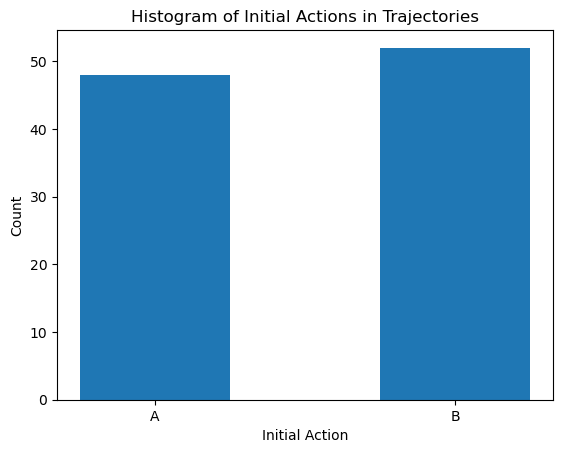

In [5]:
trajectories_data = []
num_seq = 100
np.random.seed(73)

for idx_trj in np.random.choice(len(action_sequences), num_seq, replace=False):
    traj_dict = {
        'actions': np.array(action_sequences[idx_trj]),
        'observations': np.array(observation_sequences[idx_trj])
    }
    trajectories_data.append(traj_dict)

initial_actions = [trj['actions'][0] for trj in trajectories_data]

pAct = np.zeros(2)
pA = np.count_nonzero(np.array(initial_actions) == 'A') / len(initial_actions)
pB = 1 - pA

pAct[0] = pA
pAct[1] = pB

plt.hist(initial_actions, bins = np.arange(-0.5, 2.5, 1), align = 'mid', rwidth = 0.5)
plt.xticks([0, 1], ["A", "B"])
plt.xlabel("Initial Action")
plt.ylabel("Count")
plt.title("Histogram of Initial Actions in Trajectories")
plt.show()

In [6]:
ActSpace = np.array(list(set(action for seq in action_sequences for action in seq)))
ObsSpace = np.array(list(set(obs for seq in observation_sequences for obs in seq)))
print(f"Action Space: {ActSpace}")
print(f"Observation Space: {ObsSpace}")

Action Space: ['B' 'A']
Observation Space: [0 1 2 3 4 5 6 7 8 9]


In [7]:
A = len(ActSpace)
Y = len(ObsSpace)

In [8]:
AllowedObsFromAct = np.zeros((A, Y), dtype = bool)
for trj in trajectories_data:
    actions = trj["actions"]
    observations = trj["observations"]
    for i in range(len(actions) - 1):
        act = np.where(ActSpace == actions[i])[0][0]
        obs = observations[i]
        obs_idx = np.where(ObsSpace == obs)[0][0]
        AllowedObsFromAct[act, obs_idx] = True

# Finite State Controller with 2 internal states

In [11]:
NEpochs_MAPSO = 100
M = 2
MemSpace = np.array(["M" + str(num) for num in range(M)])


FSC_M2 = controller.FSC(M = M, A = A, Y = Y,
                        mode = "inference",
                        policy_model = "softmax",
                        policy_params = {"theta": None, "zeta": None},
                        psi = np.ones(M),
                        ActSpace = ActSpace, MemSpace = MemSpace,
                        ObsSpace = ObsSpace)

FSC_M2.set_inference_params(use_gradient = False, use_MAPSO = True,
                            trainable_parameters = "all",
                            n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                            dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                            num_neighbors_mid_MAPSO = 2,
                            init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1}, # 1
                            init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                            print_params = False)
        
_ = FSC_M2.fit(trajectories_data, verbose_MAPSO=False, verbose_epochs_MAPSO=True)

Initial best value: 61.48379895145311
Iteration 1/100, best value: 61.48379895145311
Iteration 2/100, best value: 45.48458188966454
Iteration 3/100, best value: 35.61931027297076
Iteration 4/100, best value: 11.858706032098482
Iteration 5/100, best value: 5.292165951575177
Iteration 6/100, best value: 4.348302241054093
Iteration 7/100, best value: 3.6524333180254005
Iteration 8/100, best value: 3.1200931914754495
Iteration 9/100, best value: 2.9709027294967574
Iteration 10/100, best value: 2.903648480888263
Iteration 11/100, best value: 2.8417210565953646
Iteration 12/100, best value: 2.8414010607543743
Iteration 13/100, best value: 2.8230925523122177
Iteration 14/100, best value: 2.80916798071841
Iteration 15/100, best value: 2.804427170909639
Iteration 16/100, best value: 2.8037019885017163
Iteration 17/100, best value: 2.8037019885017163
Iteration 18/100, best value: 2.8031281976983546
Iteration 19/100, best value: 2.8031281976983546
Iteration 20/100, best value: 2.8031245358711363


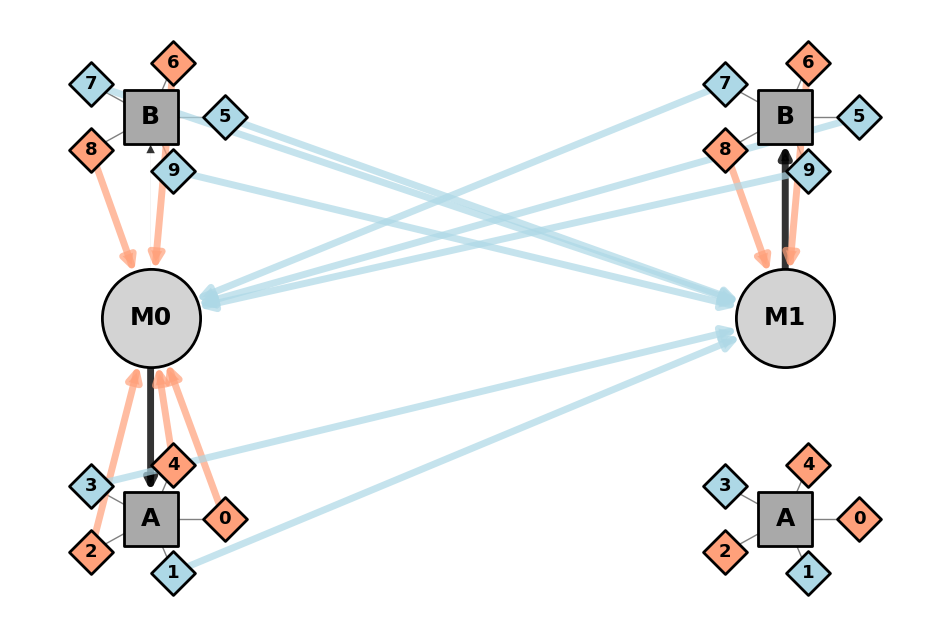

In [15]:
FSC_M2.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue",
                           "lightsalmon", "lightblue",
                           "lightsalmon", "lightblue",
                           "lightsalmon", "lightblue",
                           "lightsalmon", "lightblue"]

ax = FSC_M2.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-3, th_mem_transitions=1e-3,
                     AllowedObsFromAct=AllowedObsFromAct)
plt.show()

In [ ]:
FSC_M2.save(path)

In [13]:
NEpochs_MAPSO = 500
M = 3
MemSpace = np.array(["M" + str(num) for num in range(M)])

FSC_M3 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": None, "zeta": None},
                          psi = None,
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M3.set_inference_params(use_gradient = False, use_MAPSO = True,
                              trainable_parameters = "all",
                              n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                              dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                              num_neighbors_mid_MAPSO = 2,
                              init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1}, # 1
                              init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                              print_params = False)
        
_ = FSC_M3.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 63.12962736149652
Iteration 1/500, best value: 63.12962736149652
Iteration 2/500, best value: 54.979563653031946
Iteration 3/500, best value: 44.06719034008471
Iteration 4/500, best value: 28.06100858346732
Iteration 5/500, best value: 19.2182333405734
Iteration 6/500, best value: 13.530682508579195
Iteration 7/500, best value: 13.530682508579195
Iteration 8/500, best value: 8.389700624136836
Iteration 9/500, best value: 6.169638955200575
Iteration 10/500, best value: 6.169638955200575
Iteration 11/500, best value: 5.097257295427191
Iteration 12/500, best value: 5.080250173812135
Iteration 13/500, best value: 5.080250173812135
Iteration 14/500, best value: 5.080250173812135
Iteration 15/500, best value: 5.080250173812135
Iteration 16/500, best value: 5.080250173812135
Iteration 17/500, best value: 5.080250173812135
Iteration 18/500, best value: 4.076603230658555
Iteration 19/500, best value: 4.076603230658555
Iteration 20/500, best value: 4.076603230658555
Iteration

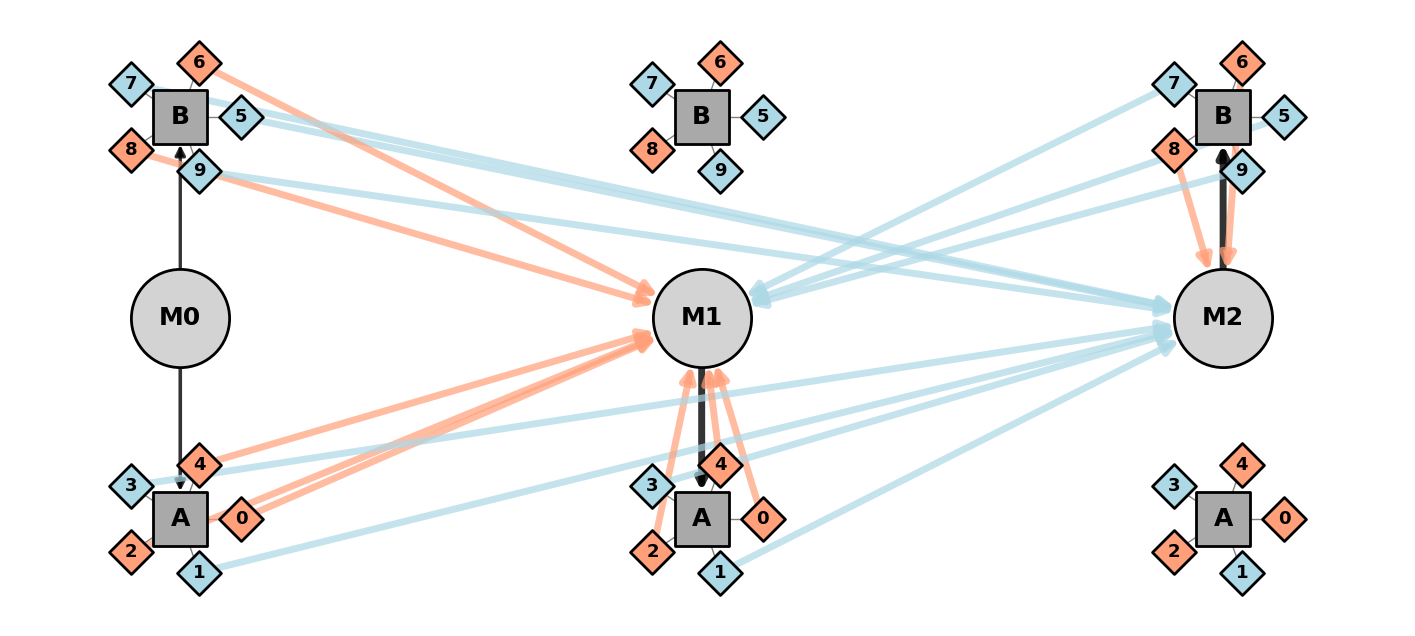

In [16]:
FSC_M3.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue",
                           "lightsalmon", "lightblue",
                           "lightsalmon", "lightblue",
                           "lightsalmon", "lightblue",
                           "lightsalmon", "lightblue"]

ax = FSC_M3.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-3, th_mem_transitions=1e-3,
                     AllowedObsFromAct = AllowedObsFromAct)
plt.show()

In [270]:
FSC_M3.save(path)

FSC saved in ../data/ParityCheck/FSC_discrete_softmax_M3_A2_Y10_trained_loss0.692347.pkl
